In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)


In [6]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
print("Head:\n", df.head())
df.info()

Shape: (1460, 81)
Head:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Sto

Jumlah Kolom yang Memiliki Missing Value: {19}


,Missing %
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


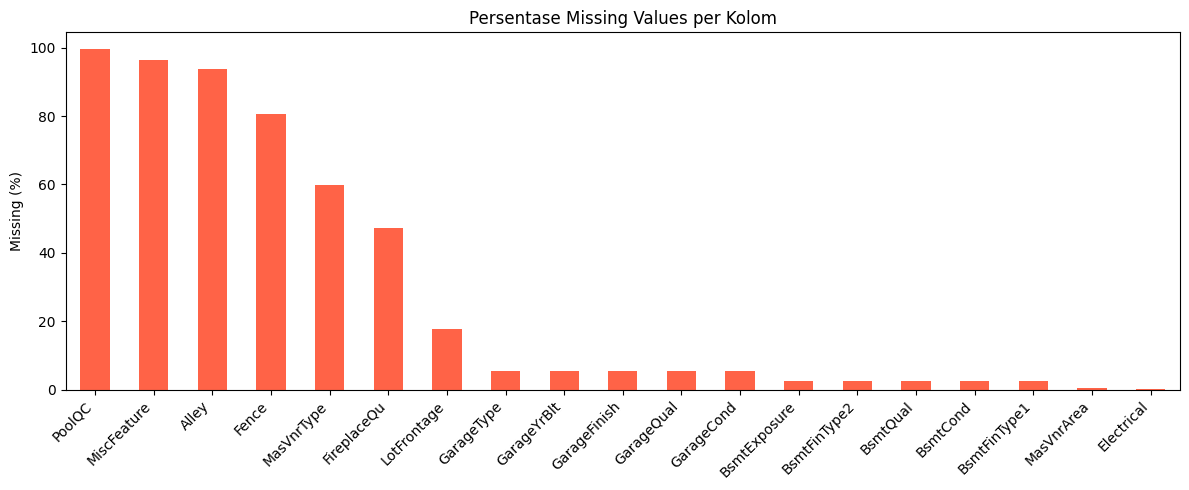

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print("Jumlah Kolom yang Memiliki Missing Value:", {len(missing_df)})
display(missing_df.to_frame(name="Missing %"))

plt.figure(figsize=(12, 5))
missing_df.plot(kind='bar', color='tomato')
plt.title('Persentase Missing Values per Kolom')
plt.ylabel('Missing (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [10]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in num_cols: #imputasi numerik dengan median
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols: #imputasi kategorikal dengan mode
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total Missing setelah Imputasi:", df.isnull().sum().sum())


Total Missing setelah Imputasi: 0


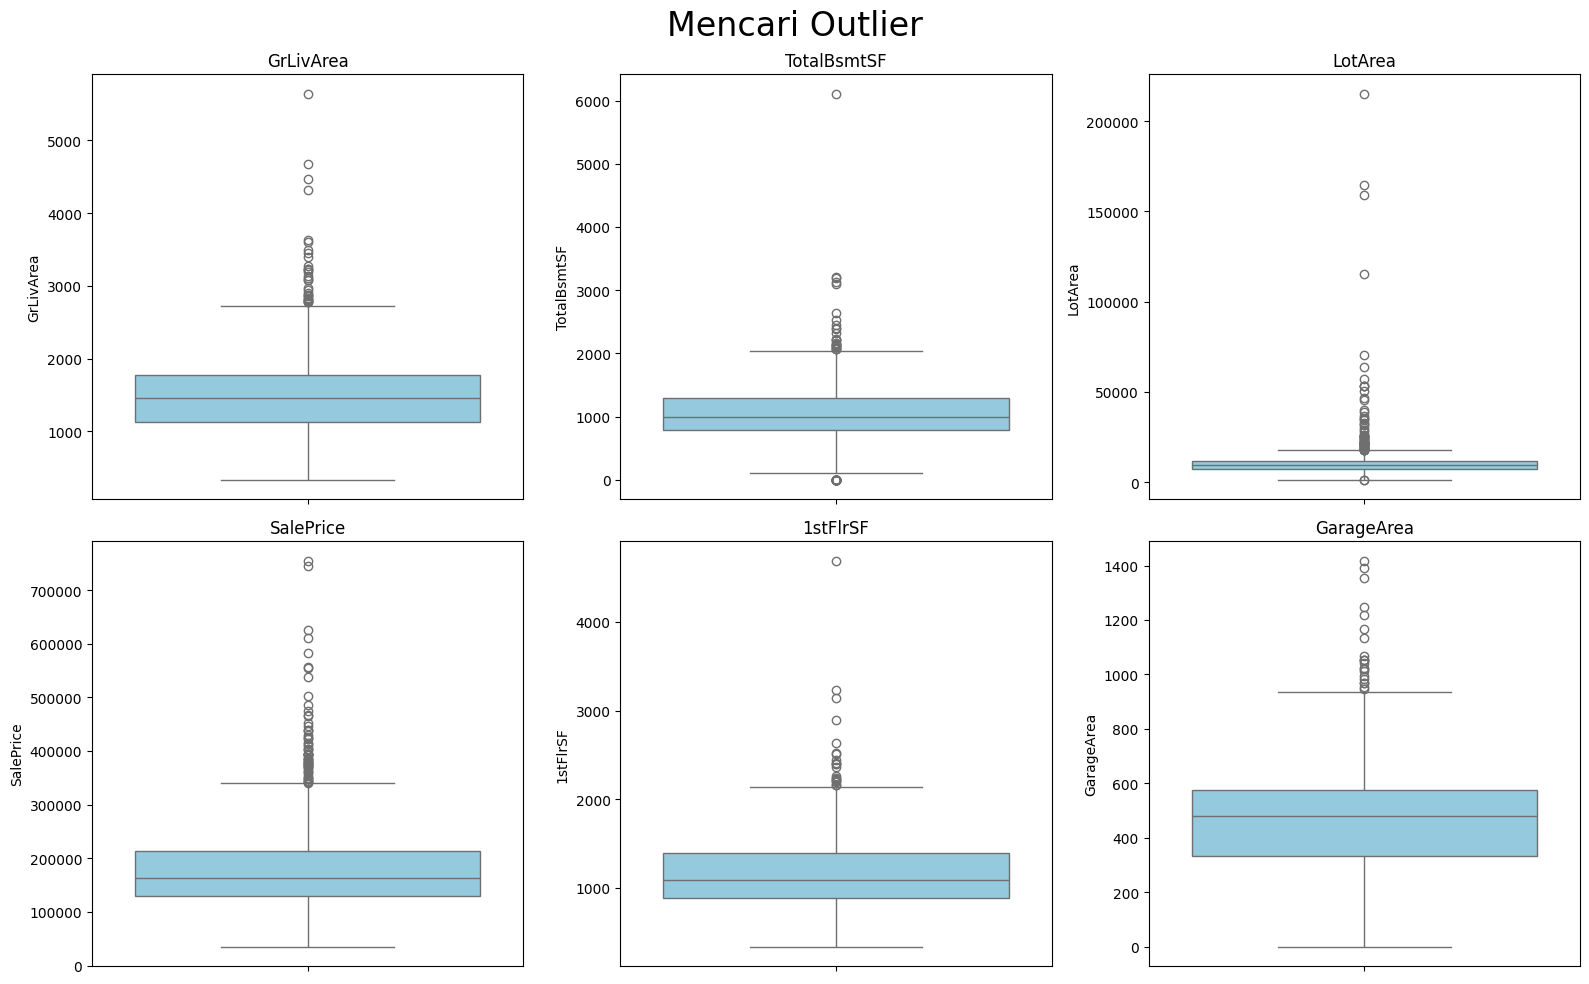

In [14]:
num_sample = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'SalePrice', '1stFlrSF', 'GarageArea']

plt.figure(figsize=(16,10))
for i, col in enumerate(num_sample, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.suptitle('Mencari Outlier', fontsize=24)
plt.tight_layout()
plt.show()

In [17]:
def cap_outlier_iqr(df, cols):
    df_copy = df.copy()
    for col in cols:
        Q1 = df_copy[col].quantile(0.25)
        Q3 =df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_copy[col] = df_copy[col].clip(lower=lower, upper=upper)
    return df_copy
num_features = [c for c in num_cols if c not in ['Id', 'SalePrice']]
df = cap_outlier_iqr(df, num_features)

print("Shape setelah Outlier Capping:", df.shape)

Shape setelah Outlier Capping: (1460, 81)


In [26]:
skewness = df[num_features].skew().sort_values(ascending=False)
print("10 Fitur Paling Skew:\n", skewness.head(10))
skewed_cols = skewness[skewness.abs() >= 1].index.tolist()

print(f"\nJumlah Kolom yang akan di Log Transform:", {len(skewed_cols)})
for col in skewed_cols:
    if col in df.columns and (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

10 Fitur Paling Skew:
 2ndFlrSF        0.800109
BsmtUnfSF       0.796931
BsmtFinSF1      0.739877
HalfBath        0.675897
1stFlrSF        0.664134
GrLivArea       0.593556
Fireplaces      0.584655
OverallCond     0.579334
BsmtFullBath    0.563057
MasVnrArea      0.480981
dtype: float64

Jumlah Kolom yang akan di Log Transform: {0}


In [27]:
scaler = MinMaxScaler()
cols_to_scale = [c for c in num_cols if c not in ['Id', 'SalePrice'] and c in df.columns]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
display(df[cols_to_scale].describe().round(3))

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.0,1460.000,1460.000,1460.000,1460.000,1460.0,1460.000,1460.000,1460.0,1460.000,1460.000,1460.000,1460.0,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.0,1460.0,1460.0,1460.0,1460.0,1460.000,1460.000
mean,0.394,0.495,0.504,0.513,0.511,0.690,0.581,0.348,0.247,0.0,0.334,0.502,0.452,0.191,0.0,0.485,0.170,0.0,0.522,0.191,0.588,0.0,0.561,0.245,0.705,0.504,0.502,0.406,0.446,0.0,0.0,0.0,0.0,0.0,0.484,0.454
std,0.344,0.227,0.222,0.172,0.241,0.241,0.344,0.430,0.243,0.0,0.256,0.198,0.199,0.239,0.0,0.199,0.207,0.0,0.184,0.251,0.190,0.0,0.193,0.256,0.225,0.212,0.221,0.429,0.414,0.0,0.0,0.0,0.0,0.0,0.246,0.332
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.000
25%,0.000,0.375,0.375,0.375,0.375,0.552,0.283,0.000,0.000,0.0,0.132,0.375,0.301,0.000,0.0,0.330,0.000,0.0,0.333,0.000,0.375,0.0,0.375,0.000,0.549,0.286,0.357,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.364,0.250
50%,0.458,0.493,0.494,0.500,0.375,0.704,0.733,0.000,0.215,0.0,0.283,0.472,0.413,0.000,0.0,0.468,0.000,0.0,0.667,0.000,0.625,0.0,0.500,0.400,0.718,0.571,0.512,0.000,0.634,0.0,0.0,0.0,0.0,0.0,0.455,0.500
75%,0.628,0.625,0.625,0.625,0.625,0.920,0.900,0.848,0.400,0.0,0.479,0.625,0.581,0.400,0.0,0.598,0.400,0.0,0.667,0.500,0.625,0.0,0.625,0.400,0.915,0.571,0.614,0.849,0.823,0.0,0.0,0.0,0.0,0.0,0.636,0.750
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,1.000,1.000,1.000,0.0,1.000,1.000,0.0,1.000,1.000,1.000,0.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,0.0,0.0,0.0,0.0,1.000,1.000


In [29]:
cat_cols_remaining = df.select_dtypes(include='object').columns.tolist()
print(f"Kolom Kategori:", len(cat_cols_remaining))
df = pd.get_dummies(df, columns=cat_cols_remaining, drop_first=True)
df.shape

Kolom Kategori: 43


(1460, 246)

Top 15 fitur berkorelasi dengan SalePrice:


,SalePrice
SalePrice,1.000000
OverallQual,0.791965
GrLivArea,0.708153
GarageCars,0.644002
TotalBsmtSF,0.636999
GarageArea,0.630138
1stFlrSF,0.620743
ExterQual_TA,0.589044
FullBath,0.560664
TotRmsAbvGrd,0.536067


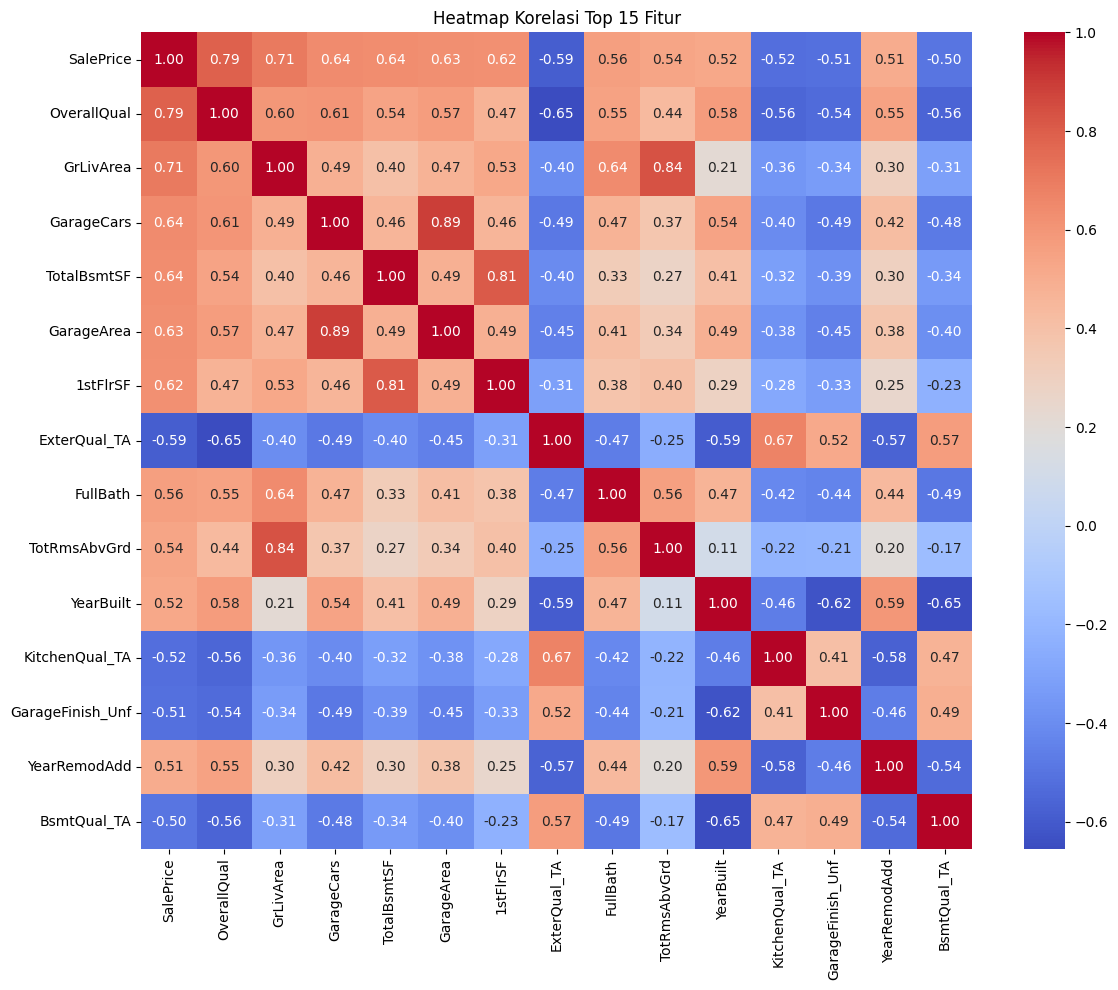

In [30]:
corr_with_target = df.corr()['SalePrice'].abs().sort_values(ascending=False)
print("Top 15 fitur berkorelasi dengan SalePrice:")
display(corr_with_target.head(15))
top_features = corr_with_target.head(15).index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi Top 15 Fitur')
plt.tight_layout()
plt.show()

In [31]:
corr_all = df.drop(columns=['SalePrice']).corr().abs()
upper_tri = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
cols_to_remove = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]
print(f"Kolom redundan: {cols_to_remove}")

df.drop(columns=cols_to_remove, inplace=True)
print(f"Shape setelah reduksi: {df.shape}")

Kolom redundan: ['RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'MasVnrType_Stone', 'ExterQual_TA', 'SaleCondition_Partial']
Shape setelah reduksi: (1460, 238)


Komponen PCA: 99
Shape X setelah PCA: (1460, 99)


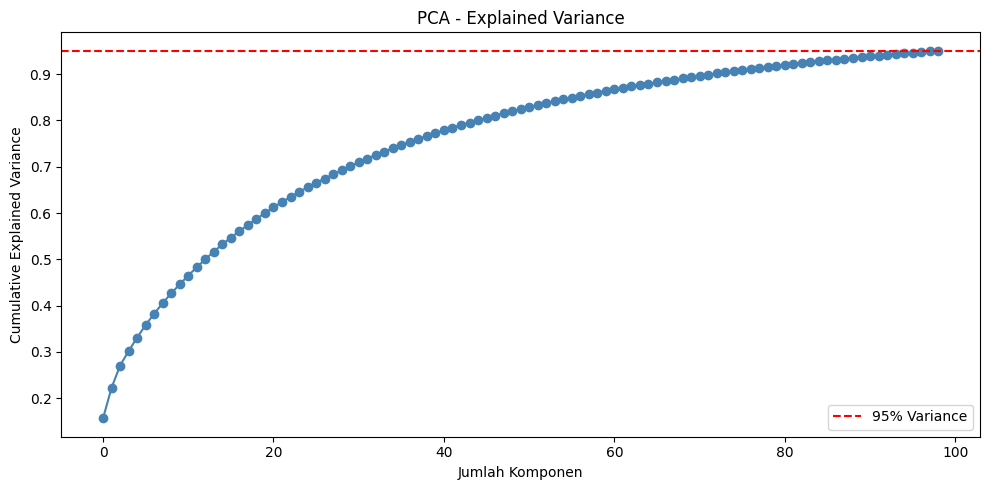

In [32]:
X = df.drop(columns=['SalePrice', 'Id'], errors='ignore')
y = df['SalePrice']

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Komponen PCA: {pca.n_components_}")
print(f"Shape X setelah PCA: {X_pca.shape}")

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_final = pd.DataFrame(X_pca, columns=pca_cols)
df_final['SalePrice'] = y.values

print(f"Shape dataset akhir: {df_final.shape}")
display(df_final.head())

df_final.to_csv('train_cleaned.csv', index=False)
print("selesai")

Shape dataset akhir: (1460, 100)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51,PC52,PC53,PC54,PC55,PC56,PC57,PC58,PC59,PC60,PC61,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,PC70,PC71,PC72,PC73,PC74,PC75,PC76,PC77,PC78,PC79,PC80,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88,PC89,PC90,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,SalePrice
0,1.962422,-0.518430,-0.181979,-0.428448,0.825454,0.211298,0.744865,-0.124846,0.316203,0.796050,0.130798,0.329150,-0.433596,-0.169378,-0.209392,-0.107492,-0.280687,0.375324,-0.096536,-0.464156,0.158204,0.082145,-0.190957,0.233031,0.004636,0.205552,-0.084623,0.058646,0.032889,-0.244378,0.091280,-0.010531,-0.179701,-0.354315,0.044438,0.266255,-0.167506,-0.158033,0.218302,0.260322,-0.117706,0.002664,-0.016983,-0.071426,0.021653,-0.181345,0.170263,-0.103684,-0.061349,0.109199,-0.183086,0.012870,-0.005917,0.103318,-0.052590,-0.027103,-0.054790,-0.157291,-0.062120,-0.041924,-0.003822,-0.004858,-0.085010,0.091868,0.002890,0.060728,-0.023458,0.043818,-0.050406,0.017560,0.074345,0.055040,-0.077472,-0.031896,-0.057361,-0.065864,0.005165,-0.077872,0.025424,-0.012833,0.029049,-0.000999,0.009694,0.083580,-0.014367,0.020357,-0.058283,-0.011918,0.007635,0.011631,0.010534,-0.035960,-0.049230,0.077793,0.032537,-0.001783,0.021881,-0.045935,-0.065711,208500
1,-0.026487,1.346736,-0.382720,-0.239585,0.097463,-0.588083,-0.618256,0.486058,0.155136,-0.141429,-0.132308,-0.791692,0.096224,0.978860,0.005903,-0.097788,0.095255,1.131149,-0.220103,0.457926,-0.363934,0.179519,0.151016,-1.079415,-0.115863,0.508262,0.295950,-0.328500,0.518660,-0.144528,-0.197484,0.478141,-0.121891,-0.142005,-0.096361,-0.504179,-0.009243,-0.374640,0.233018,-0.210463,-0.298192,0.228760,-0.065069,-0.132792,-0.403363,0.121148,-0.256940,0.289487,0.083387,-0.359126,-0.002594,0.512064,-0.376794,-0.207996,0.136680,0.234790,-0.008458,0.221197,-0.355564,0.086266,-0.137474,-0.197169,-0.050260,0.062300,-0.129655,-0.300218,-0.082350,0.107832,0.128886,-0.145946,-0.227509,0.253177,0.489973,0.090223,0.246646,0.056105,-0.034047,-0.281313,0.063047,-0.052041,-0.197644,0.280233,-0.222339,0.249389,-0.284660,0.084825,-0.076328,-0.168896,-0.145810,-0.057652,-0.171551,0.174358,0.005083,0.136930,-0.023253,-0.005679,0.010147,-0.020722,-0.060614,181500
2,2.312079,0.031440,-0.901465,-0.409549,0.106479,-0.316448,0.219886,0.162236,0.179515,0.451363,0.208675,0.052033,-0.190586,0.298696,0.013378,-0.269233,-0.118711,0.464895,0.771405,-0.510279,0.677610,-0.068803,0.080518,-0.048240,-0.278812,-0.282203,0.086440,0.707866,-0.036309,-0.259959,0.153466,-0.209883,-0.189789,-0.179450,-0.146753,0.330008,-0.030486,0.092453,0.400043,0.189140,0.028940,-0.192380,-0.037516,0.276425,0.217728,0.041563,0.048339,0.018367,0.163239,0.029397,0.052524,-0.120543,0.115024,-0.118948,0.028501,-0.014297,-0.220781,-0.047252,0.017635,-0.022653,0.053839,-0.069254,0.019046,0.161045,-0.004391,0.033342,0.047547,0.135099,0.076190,0.097673,0.005913,0.019796,-0.089698,-0.090811,-0.087132,-0.042153,0.089350,-0.117415,-0.109614,-0.045951,0.039667,-0.129168,0.031254,0.145134,-0.069742,0.000744,0.019192,-0.072649,0.048527,-0.041941,0.060518,-0.018147,-0.124674,0.123632,0.066466,-0.029615,0.086972,0.012495,0.002589,223500
3,-0.531249,-0.998634,-0.404031,0.397374,-1.183378,-0.252781,0.571889,-0.787325,-0.003767,-0.025800,0.243554,-0.190550,-0.408451,-0.360413,0.938899,-0.376057,0.141035,-0.162376,-0.014989,0.001508,-0.022506,-0.003930,-0.360489,0.763777,0.474599,-0.313095,-0.474943,-0.141104,0.264556,-0.585892,-0.071853,0.099293,-0.206503,-0.099563,-0.455405,-0.325558,0.223373,0.589862,0.488349,0.039536,0.253327,-0.020450,-0.084995,-0.057227,-0.136868,0.179001,0.224273,-0.029806,-0.615223,0.733393,-0.222507,0.467124,-0.329129,-0.104528,-0.356475,0.138858,-0.305728,0.213950,-0.000572,-0.067477,-0.469584,0.192734,0.375735,0.092669,0.195990,0.365530,-0.389501,0.197

selesai
